# Xarray-Spatial GeoTIFF I/O: Reading, writing, and accessor shortcuts

GeoTIFF is the standard raster format in geospatial work. xarray-spatial has a pure-Python reader and writer (no GDAL) that follows xarray naming: `open_geotiff` to read, `to_geotiff` to write.

### What you'll build

1. [Write and read back a GeoTIFF](#Write-and-read-back) with `to_geotiff` and `open_geotiff`
2. [Write from a DataArray accessor](#Accessor-write) using `da.xrs.to_geotiff()`
3. [Windowed read via Dataset accessor](#Windowed-read-via-Dataset) using `ds.xrs.open_geotiff()` to crop a large file to an existing spatial extent
4. [Stitch tiles with write_vrt](#VRT-mosaic) to build a virtual mosaic from multiple GeoTIFFs

![GeoTIFF I/O preview](images/geotiff_io_preview.png)

Imports: xrspatial for the accessor, plus the GeoTIFF functions directly.

In [1]:
%matplotlib inline
import tempfile
import os

import numpy as np
import xarray as xr

import matplotlib.pyplot as plt

import xrspatial
from xrspatial.geotiff import open_geotiff, to_geotiff, write_vrt

## Synthetic elevation raster

A 200x300 grid of fake elevation with geographic coordinates (WGS 84). We'll reuse this throughout.

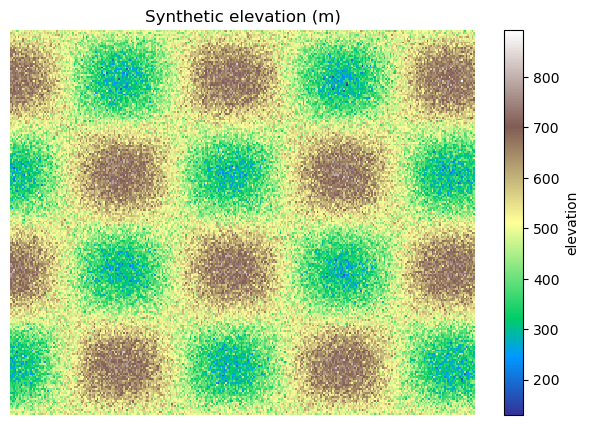

In [2]:
rng = np.random.default_rng(42)
H, W = 200, 300

# Two overlapping sine waves + noise for terrain-like structure
yy, xx = np.meshgrid(np.linspace(0, 4 * np.pi, H),
                      np.linspace(0, 6 * np.pi, W), indexing='ij')
elevation = 500 + 200 * np.sin(yy) * np.cos(xx * 0.7) + 50 * rng.standard_normal((H, W))
elevation = elevation.astype(np.float32)

# Geographic coordinates near Portland, OR
y = np.linspace(45.6, 45.4, H)   # north to south
x = np.linspace(-122.8, -122.5, W)

da = xr.DataArray(
    elevation, dims=['y', 'x'],
    coords={'y': y, 'x': x},
    name='elevation',
    attrs={'crs': 4326},
)

da.plot.imshow(size=5, aspect=W / H, cmap='terrain')
plt.title('Synthetic elevation (m)')
plt.gca().set_axis_off()
plt.show()

Covers a small patch near Portland, OR. Values are meters, from valley floor to ridgeline. The CRS lives in the DataArray's attrs, so `to_geotiff` embeds it automatically.

In [3]:
da

<xarray.DataArray 'elevation' (y: 200, x: 300)> Size: 240kB
array([[515.23584, 448.0008 , 537.5226 , ..., 481.40427, 412.1639 ,
        516.3998 ],
       [598.98865, 435.91577, 555.7634 , ..., 551.45496, 522.611  ,
        421.46262],
       [550.96246, 496.29047, 588.8162 , ..., 478.49066, 544.9579 ,
        443.5986 ],
       ...,
       [516.7113 , 548.19977, 523.5575 , ..., 448.2582 , 469.20718,
        496.94867],
       [564.23895, 456.79202, 443.16757, ..., 442.958  , 461.8408 ,
        445.42407],
       [532.1338 , 469.7007 , 504.0479 , ..., 464.74902, 489.26068,
        558.9692 ]], shape=(200, 300), dtype=float32)
Coordinates:
  * y        (y) float64 2kB 45.6 45.6 45.6 45.6 45.6 ... 45.4 45.4 45.4 45.4
  * x        (x) float64 2kB -122.8 -122.8 -122.8 ... -122.5 -122.5 -122.5
Attributes:
    crs:      4326

## Write and read back

`to_geotiff(data, path)` writes a DataArray or numpy array as a GeoTIFF. `open_geotiff(path)` reads it back. Coordinates, CRS, and nodata survive the round trip via the file's GeoKeys.

In [4]:
tmpdir = tempfile.mkdtemp(prefix='xrs_geotiff_nb_')
path = os.path.join(tmpdir, 'elevation.tif')

# Write
to_geotiff(da, path, compression='deflate')
print(f'Wrote {os.path.getsize(path):,} bytes')

# Read back
loaded = open_geotiff(path)

# Verify round-trip
print(f'Shape: {loaded.shape}')
print(f'CRS:   {loaded.attrs.get("crs")}')
print(f'Name:  {loaded.name}')
print(f'Match: {np.allclose(loaded.values, da.values)}')

Wrote 212,414 bytes
Shape: (200, 300)
CRS:   4326
Name:  elevation
Match: True


Round-tripped data matches the original. `open_geotiff` derived the DataArray name from the filename.

## Accessor write

The `.xrs.to_geotiff()` accessor does the same thing if you prefer chaining. Same idea as `da.to_netcdf()`.

In [5]:
accessor_path = os.path.join(tmpdir, 'via_accessor.tif')

# Write using the accessor
da.xrs.to_geotiff(accessor_path, compression='lzw')

# Read back and verify
loaded2 = open_geotiff(accessor_path)
print(f'Shape: {loaded2.shape}')
print(f'Match: {np.allclose(loaded2.values, da.values)}')

Shape: (200, 300)
Match: True


<div class="alert alert-block alert-info">
<b>Dataset write.</b> The Dataset accessor also has <code>.xrs.to_geotiff()</code>. It picks the first 2D variable with y/x dims, or you can specify <code>var='elevation'</code> explicitly.
</div>

## Windowed read via Dataset

`ds.xrs.open_geotiff(path)` reads only the pixels that overlap the Dataset's y/x coordinates, so you skip loading the full file when you only need a subregion.

We'll make a small template Dataset covering the southeast quadrant, then window-read the full raster through it.

Full raster:  (200, 300)
Cropped:      (81, 121)


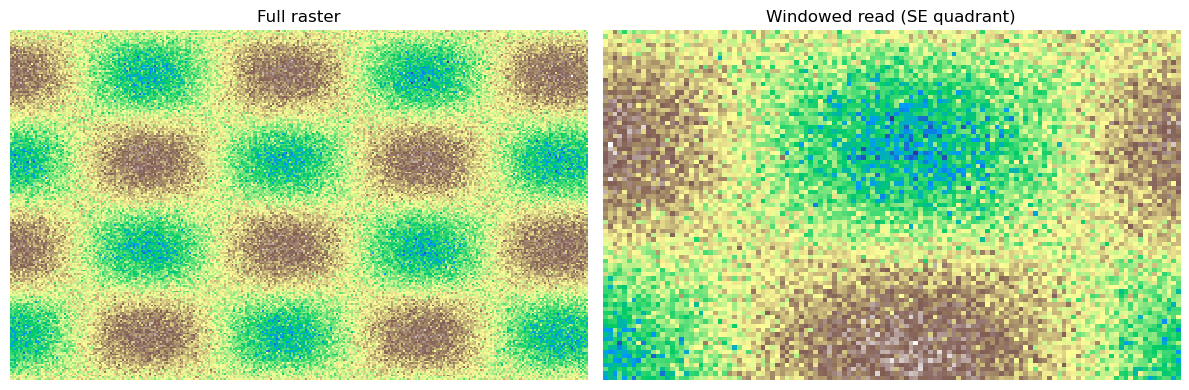

In [6]:
# Template covering the SE quadrant
y_sub = da.coords['y'].values[100:180]
x_sub = da.coords['x'].values[150:270]

template = xr.Dataset({
    'placeholder': xr.DataArray(
        np.zeros((len(y_sub), len(x_sub)), dtype=np.float32),
        dims=['y', 'x'],
        coords={'y': y_sub, 'x': x_sub},
    )
})

# Windowed read: only loads the overlapping region
cropped = template.xrs.open_geotiff(path)

print(f'Full raster:  {da.shape}')
print(f'Cropped:      {cropped.shape}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
da.plot.imshow(ax=axes[0], cmap='terrain', add_colorbar=False)
axes[0].set_title('Full raster')
axes[0].set_axis_off()

cropped.plot.imshow(ax=axes[1], cmap='terrain', add_colorbar=False)
axes[1].set_title('Windowed read (SE quadrant)')
axes[1].set_axis_off()
plt.tight_layout()
plt.show()

The result is smaller than the full 200x300 raster. Only the overlapping region was read from disk.

## VRT mosaic

`write_vrt` writes a lightweight XML file that stitches multiple GeoTIFFs into one virtual raster. The tiles aren't copied, just referenced.

In [7]:
# Split into 4 tiles and write each
tiles = [
    ('nw', da[:100, :150]),
    ('ne', da[:100, 150:]),
    ('sw', da[100:, :150]),
    ('se', da[100:, 150:]),
]
tile_paths = []
for name, tile in tiles:
    p = os.path.join(tmpdir, f'tile_{name}.tif')
    to_geotiff(tile, p, compression='deflate')
    tile_paths.append(p)
    print(f'{name}: {tile.shape} -> {os.path.getsize(p):,} bytes')

# Stitch into a VRT
vrt_path = os.path.join(tmpdir, 'mosaic.vrt')
write_vrt(vrt_path, tile_paths)
print(f'\nVRT: {os.path.getsize(vrt_path):,} bytes')

# Read the mosaic back
mosaic = open_geotiff(vrt_path)
print(f'Mosaic shape: {mosaic.shape}')
print(f'Matches original: {np.allclose(mosaic.values, da.values)}')

nw: (100, 150) -> 54,041 bytes
ne: (100, 150) -> 54,052 bytes
sw: (100, 150) -> 54,090 bytes
se: (100, 150) -> 54,051 bytes

VRT: 2,178 bytes
Mosaic shape: (200, 300)
Matches original: True


The VRT is a few hundred bytes of XML. `open_geotiff` assembles the tiles when you read it.

## Supported features by tier

`xrspatial.geotiff.SUPPORTED_FEATURES` is the source of truth for which features sit in the stable core, which are advanced but supported, which are experimental, and which require an opt-in flag because they do not round-trip through external readers. The table below is built from that constant so the documentation cannot drift from the code (issue #2137).

Tiers:

- **stable** -- the path a new user should be on. Local file in, local file out, lossless codec, axis-aligned grid.
- **advanced** -- works and is tested, but the caller should know the failure mode (cloud cost, partial VRT mosaics, rotated transforms drop on write, BigTIFF promotion, etc.).
- **experimental** -- no claim about cross-backend numerical parity or external interop. Tier 3 codecs (`lerc`, `jpeg2000` / `j2k`, `lz4`) require `allow_experimental_codecs=True` on `to_geotiff` and `write_geotiff_gpu`; the GPU read/write paths use `gpu=True` as their explicit opt-in.
- **internal_only** -- the strictest tier. `compression='jpeg'` writes self-contained JFIF tiles without the TIFF JPEGTables tag, so the output decodes through xrspatial but not libtiff / GDAL / rasterio. Requires the dedicated `allow_internal_only_jpeg=True` flag (issue #1845); `allow_experimental_codecs` does not cover it.

In [ ]:
from xrspatial.geotiff import SUPPORTED_FEATURES

# Render SUPPORTED_FEATURES as a markdown table grouped by tier.
# This cell renders from the live constant so the table tracks any
# future additions to the feature inventory.
from collections import defaultdict
from IPython.display import Markdown

_TIER_ORDER = ['stable', 'advanced', 'experimental', 'internal_only']
_by_tier = defaultdict(list)
for name, tier in SUPPORTED_FEATURES.items():
    _by_tier[tier].append(name)

lines = ['| Feature | Tier |', '| --- | --- |']
for tier in _TIER_ORDER:
    for name in sorted(_by_tier[tier]):
        lines.append(f'| `{name}` | {tier} |')

Markdown('\n'.join(lines))

In [8]:
# Clean up temp files
import shutil
shutil.rmtree(tmpdir, ignore_errors=True)

### References

- [GeoTIFF specification (OGC)](https://www.ogc.org/standard/geotiff/)
- [Cloud Optimized GeoTIFF](https://www.cogeo.org/)
- [xarray I/O naming conventions](https://docs.xarray.dev/en/stable/user-guide/io.html)